In [19]:
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv('train.csv')    
test = pd.read_csv('test.csv')  
submission = pd.read_csv('sample_submission.csv')




* ### EDA
Om de data goed te kunnen gebruiken moet het voldoen aan wat voorwaarden zodat we het kunnen verwerken met Scikit Learn. In de onderstaande code word gekeken of er aan deze voorwaarden voldaan wordt. Zo wordt er gekeken naar of er ontbrekende of dubbele waarden zijn, of het numerieke waarden zijn en wat de form van de dataset is.

In [20]:
def VoldoetDf(df, naam):

    print(f"Analyse van DataFrame: {naam}")

    # Controleren op missende waarden
    missende_waarden = df.isnull().sum()
    if sum(missende_waarden) > 0:
            print(f'Er zijn {sum(missende_waarden)} missende waarden')
    else:
        print('Er zijn geen missende waarden')

    # Controleren op dubbele rijen
    dubbele_rijen = df.duplicated().sum()
    if dubbele_rijen > 0:
        print(f'Er zijn {dubbele_rijen} dubbele rijen')
    else:
        print('Er zijn geen dubbele rijen')

    # Controleer de datatypes van de kolommen
    data_types = df.dtypes
    print("Data types:", data_types.unique())

    # Controleer de vorm van de DataFrame
    print(f'De DataFrame heeft {df.shape[0]} rijen en {df.shape[1]} kolommen')

    # Witregel voor betere leesbaarheid
    print()
    
VoldoetDf(train, 'train')
VoldoetDf(test, 'test')
VoldoetDf(submission, 'submission')


Analyse van DataFrame: train
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64') dtype('float64') dtype('bool')]
De DataFrame heeft 33550 rijen en 22 kolommen

Analyse van DataFrame: test
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64') dtype('float64') dtype('bool')]
De DataFrame heeft 8388 rijen en 21 kolommen

Analyse van DataFrame: submission
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64')]
De DataFrame heeft 8388 rijen en 2 kolommen



De data voldoet aan alle eisen van Scikit Learn. Er zijn namelijk geen missende waarden, alle data is numeriek (of een boolean) en de testset en de datasets zijn tweedimensionaal. De testset en de submission set is ook even groot en zou dus geen problemen moeten opleveren.

Toon de datatypes en basisstatistieken van iedere kolom.

In [21]:
display(train.describe(), train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33550 entries, 0 to 33549
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              33550 non-null  int64  
 1   age                             33550 non-null  float64
 2   hypertension                    33550 non-null  int64  
 3   heart_disease                   33550 non-null  int64  
 4   avg_glucose_level               33550 non-null  float64
 5   bmi                             33550 non-null  float64
 6   gender_Female                   33550 non-null  bool   
 7   gender_Male                     33550 non-null  bool   
 8   gender_Other                    33550 non-null  bool   
 9   ever_married_No                 33550 non-null  bool   
 10  ever_married_Yes                33550 non-null  bool   
 11  work_type_Govt_job              33550 non-null  bool   
 12  work_type_Never_worked          

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,36746.393353,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,20906.519131,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,1.000000,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,18763.250000,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,36862.000000,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,54757.500000,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


None

We onderzoeken de relatie tussen onze features onderling en de relatie met onze target. Hiermee kunnen we voorkomen dat er multicollineariteit optreed in ons model. In de onderstaande cel kijken we welke features een hoge correlatie met elkaar hebben.

In [22]:
corr_matrix = train.corr(numeric_only=True)

# Filter paren met een absolute correlatie groter dan 0.3 (exclusief de diagonaal van 1.0)
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # Voorkomt dubbele paren en de correlatie van een kolom met zichzelf
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} - {col2}: {corr_val:.2f}")


age - ever_married_No: -0.69
age - ever_married_Yes: 0.69
age - work_type_children: -0.64
gender_Female - gender_Male: -1.00
ever_married_No - ever_married_Yes: -1.00
ever_married_No - work_type_children: 0.55
ever_married_Yes - work_type_children: -0.55
Residence_type_Rural - Residence_type_Urban: -1.00


We zien dat sommige features een perfecte correlatie hebben en dat is heel logisch. De features zijn dummy kolommen en zijn uit de kolom voortgekomen. Om dit op te lossen kunnen we simpelweg 1 van de dummy kolommen verwijderen.

In [23]:
drop_columns = ['gender_Female', 'ever_married_No', 'Residence_type_Rural', 'smoking_status_never smoked', 'work_type_Private']
train = train.drop(columns=drop_columns)

Als we nu kijken welke features nog een hoge correlatie hebben zien we dat het er een stuk minder zijn.

In [24]:
corr_matrix = train.corr(numeric_only=True)

# Filter paren met een absolute correlatie groter dan 0.3 (exclusief de diagonaal van 1.0)
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # Voorkomt dubbele paren en de correlatie van een kolom met zichzelf
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} - {col2}: {corr_val:.2f}")

age - ever_married_Yes: 0.69
age - work_type_children: -0.64
ever_married_Yes - work_type_children: -0.55


De correlatie tussen deze features is nog niet hoog genoeg om voor multicollineariteit te zorgen, omdat daar een sterke correlatie van minstens 0.7 voor nodig is.

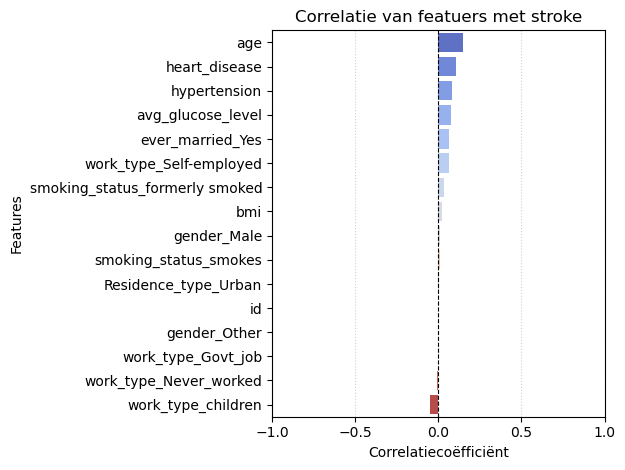

In [ ]:
target_col = 'stroke'

# 2. Bereken de correlaties en sorteer van hoog naar laag
correlations = train.corr()[target_col].drop(target_col).sort_values(ascending=False)

# 3. Visualisatie met een horizontaal staafdiagram
sns.barplot(x=correlations.values, y=correlations.index, hue=correlations.index, legend=False, palette='coolwarm')
plt.title(f'Correlatie van featuers met stroke')
plt.xlabel('Correlatiecoëfficiënt')
plt.ylabel('Features')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)  # Referentielijn op 0
plt.xlim(-1, 1)  # Bereik vastzetten tussen -1 en 1
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

We zien dat de features geen grote correlatie hebben met de target. Dit betekent dat ons model naar alle features zal moeten gaan kijken om een goede voorspelling te kunnen maken.

### Conclusie EDA:
De data voldoet al aan alle eisen van machine learning met Scikit Learn. Er waren features die te veel met elkaar correleerde, maar dat is opgelost door bepaalde features te verwijderen. Er zijn geen features die veel overeenkomen met onze target dus we zullen naar alle features moeten gaan kijken.